# t-SNE: IMU feature space by pose source

Embeds the **same feature vectors the classifier uses** (`imu_real_windows` and `imu_synthetic_windows`
from `build_windowed_multimodal_dataset`) in 2D via t-SNE and colours them by:

1. **IMU domain** — real vs synthetic (do they overlap?)
2. **Emotion** — are classes separable inside each domain?
3. **Pose source** — real-pose synthetic IMU vs Kimodo-pose synthetic IMU

This directly tests the two hypotheses for why more Kimodo samples don't improve the classifier:
- H1: Kimodo synthetic IMU is not label-discriminative (classes mix regardless of label)
- H2: Kimodo synthetic IMU is just shifted away from real IMU (domain gap), but internally structured

In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

PROJECT_ROOT

PosixPath('/home/henriquesouza/IMUGPT')

## Configuration

Reuses the same paths and dataset config as `classifiers_pose_experiments.ipynb`.

In [2]:
REAL_OUTPUT_ROOT   = PROJECT_ROOT / 'output' / 'exp_real_pose'
SYNTHETIC_MANIFEST = PROJECT_ROOT / 'output' / 'exp_synthetic_pose' / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST     = PROJECT_ROOT / 'output' / 'exp_mixed_pose'     / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG     = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors_effectors_20' / 'kimodo_anchor_catalog.jsonl'

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode='acc_euler',
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)

# t-SNE parameters
MAX_WINDOWS_PER_CAPTURE = 40   # cap to keep t-SNE tractable
TSNE_PERPLEXITY = 40
TSNE_RANDOM_STATE = 42
PCA_COMPONENTS = 50            # PCA pre-reduction before t-SNE

RNG = np.random.default_rng(42)

## Helpers

In [3]:
from pose_module.robot_emotions.metadata import get_protocol_info


def _load_real_manifest_index(real_output_root: Path) -> pd.DataFrame:
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':    str(e['clip_id']),
            'domain':     str(e['domain']),
            'user_id':    int(e['user_id']),
            'tag_number': int(e['tag_number']),
            'take_id':    e.get('take_id'),
            'clip_dir':   clip_dir,
        })
    return pd.DataFrame(rows).set_index('clip_id')


def _load_anchor_catalog_index(anchor_catalog_path: Path) -> dict:
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index


def _build_synthetic_capture_table(
    manifest_path: Path,
    real_index: pd.DataFrame,
    anchor_index: dict,
    *,
    pose_kind_filter=None,
) -> pd.DataFrame:
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts = e.get('artifacts', {})
            pose3d_npz = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            ref_clip_id = str(e['clip_id'])
        else:
            va = e.get('virtual_imu_artifacts', {})
            pose3d_npz = va.get('pose3d_npz_path')
            virtual_imu_npz = va.get('virtual_imu_npz_path')
            ref_clip_id = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        emotion  = str(protocol.get('emotion', ''))
        modality = str(protocol.get('modality', ''))
        stimulus = str(protocol.get('stimulus', 'None'))

        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None
        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])

        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            emotion,
            'modality':                           modality,
            'stimulus':                           stimulus,
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group'] = df.apply(lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1)
    df['flat_tag'] = df.apply(lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1)
    df['frame_aligned_available'] = False
    return df.reset_index(drop=True)


def flatten_imu_windows(windows: np.ndarray) -> np.ndarray:
    """[N, T, S, C] -> [N, T*S*C] mean-std normalised per sample."""
    N = windows.shape[0]
    flat = windows.reshape(N, -1).astype(np.float32)
    mu = flat.mean(axis=1, keepdims=True)
    sigma = flat.std(axis=1, keepdims=True)
    return (flat - mu) / np.maximum(sigma, 1e-8)


def subsample(features, metadata, max_per_capture, rng):
    """Keep at most max_per_capture windows per capture_id."""
    if max_per_capture is None:
        return features, metadata
    keep = []
    for _, grp in metadata.groupby('capture_id'):
        idx = grp.index.to_numpy()
        if len(idx) > max_per_capture:
            idx = rng.choice(idx, size=max_per_capture, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    keep = np.sort(keep)
    return features[keep], metadata.iloc[keep].reset_index(drop=True)


def run_tsne(features: np.ndarray, pca_components: int, perplexity: float, random_state: int) -> np.ndarray:
    n_pca = min(pca_components, features.shape[0] - 1, features.shape[1])
    reduced = PCA(n_components=n_pca, random_state=random_state).fit_transform(features)
    safe_perp = min(perplexity, reduced.shape[0] - 1)
    return TSNE(n_components=2, perplexity=safe_perp, init='pca',
                learning_rate='auto', random_state=random_state).fit_transform(reduced)


REAL_INDEX   = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest: {len(REAL_INDEX)} clips | Anchor catalog: {len(ANCHOR_INDEX)} windows')

Real manifest: 89 clips | Anchor catalog: 3726 windows


## Build datasets

Builds the three windowed datasets once (same as the classifier experiments) and concatenates
real + synthetic windows with a `pose_source` tag for colouring.

In [4]:
# --- real pose ---
CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
BUNDLE_REAL   = build_windowed_multimodal_dataset(REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=CAPTURES_REAL)
print('real_pose samples:', len(BUNDLE_REAL['metadata']))

# --- synthetic pose (Kimodo only) ---
CAPTURES_SYNTH = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
BUNDLE_SYNTH   = build_windowed_multimodal_dataset(REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=CAPTURES_SYNTH)
print('synthetic_pose samples:', len(BUNDLE_SYNTH['metadata']))

real_pose samples: 4075
synthetic_pose samples: 6461


---
## H1 — Are real and Kimodo synthetic IMU distributions separated?

Embeds `imu_real_windows` (real pose experiment) and `imu_synthetic_windows` (Kimodo pose experiment)
together. If they cluster separately → large domain gap. If they overlap → gap is manageable.

In [5]:
# Real IMU windows from real-pose experiment
feat_real_imu  = flatten_imu_windows(np.asarray(BUNDLE_REAL['imu_real_windows']))
meta_real_imu  = BUNDLE_REAL['metadata'].copy()
meta_real_imu['imu_source'] = 'real_imu'

# Synthetic IMU windows from Kimodo-pose experiment
feat_kimodo_imu = flatten_imu_windows(np.asarray(BUNDLE_SYNTH['imu_synthetic_windows']))
meta_kimodo_imu = BUNDLE_SYNTH['metadata'].copy()
meta_kimodo_imu['imu_source'] = 'kimodo_imu'

# Also add real-pose synthetic IMU for comparison
feat_realpose_synth_imu = flatten_imu_windows(np.asarray(BUNDLE_REAL['imu_synthetic_windows']))
meta_realpose_synth_imu = BUNDLE_REAL['metadata'].copy()
meta_realpose_synth_imu['imu_source'] = 'realpose_synth_imu'

# Subsample to keep t-SNE fast
feat_real_imu,          meta_real_imu          = subsample(feat_real_imu,          meta_real_imu,          MAX_WINDOWS_PER_CAPTURE, RNG)
feat_kimodo_imu,        meta_kimodo_imu        = subsample(feat_kimodo_imu,        meta_kimodo_imu,        MAX_WINDOWS_PER_CAPTURE, RNG)
feat_realpose_synth_imu, meta_realpose_synth_imu = subsample(feat_realpose_synth_imu, meta_realpose_synth_imu, MAX_WINDOWS_PER_CAPTURE, RNG)

feat_h1 = np.concatenate([feat_real_imu, feat_realpose_synth_imu, feat_kimodo_imu], axis=0)
meta_h1 = pd.concat([meta_real_imu, meta_realpose_synth_imu, meta_kimodo_imu], ignore_index=True)

print('Running t-SNE on', feat_h1.shape[0], 'windows …')
emb_h1 = run_tsne(feat_h1, PCA_COMPONENTS, TSNE_PERPLEXITY, TSNE_RANDOM_STATE)
print('Done.')

Running t-SNE on 12671 windows …
Done.


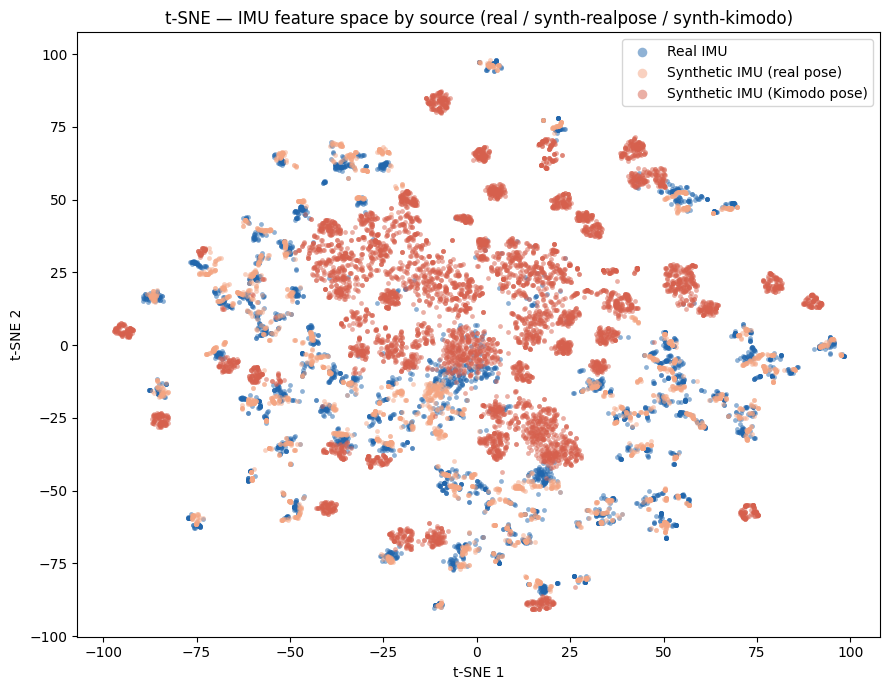

In [6]:
SOURCE_COLORS = {
    'real_imu':            '#2166ac',   # blue
    'realpose_synth_imu':  '#f4a582',   # light orange
    'kimodo_imu':          '#d6604d',   # red
}
SOURCE_LABELS = {
    'real_imu':            'Real IMU',
    'realpose_synth_imu':  'Synthetic IMU (real pose)',
    'kimodo_imu':          'Synthetic IMU (Kimodo pose)',
}

fig, ax = plt.subplots(figsize=(9, 7))
for src, color in SOURCE_COLORS.items():
    mask = meta_h1['imu_source'] == src
    ax.scatter(emb_h1[mask, 0], emb_h1[mask, 1],
               c=color, label=SOURCE_LABELS[src],
               s=12, alpha=0.5, linewidths=0)
ax.set_title('t-SNE — IMU feature space by source (real / synth-realpose / synth-kimodo)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=2, framealpha=0.8)
fig.tight_layout()
plt.show()

---
## H2 — Is the Kimodo synthetic IMU internally label-discriminative?

t-SNE of **only the Kimodo synthetic IMU windows**, coloured by emotion and modality.
If classes cluster → Kimodo encodes label information (domain gap is the only problem).
If classes mix → Kimodo generates label-agnostic motion (more samples won't help).

In [7]:
print('Running t-SNE on Kimodo-only synthetic IMU …')
emb_kimodo = run_tsne(feat_kimodo_imu, PCA_COMPONENTS, TSNE_PERPLEXITY, TSNE_RANDOM_STATE)
print('Done.')

Running t-SNE on Kimodo-only synthetic IMU …
Done.


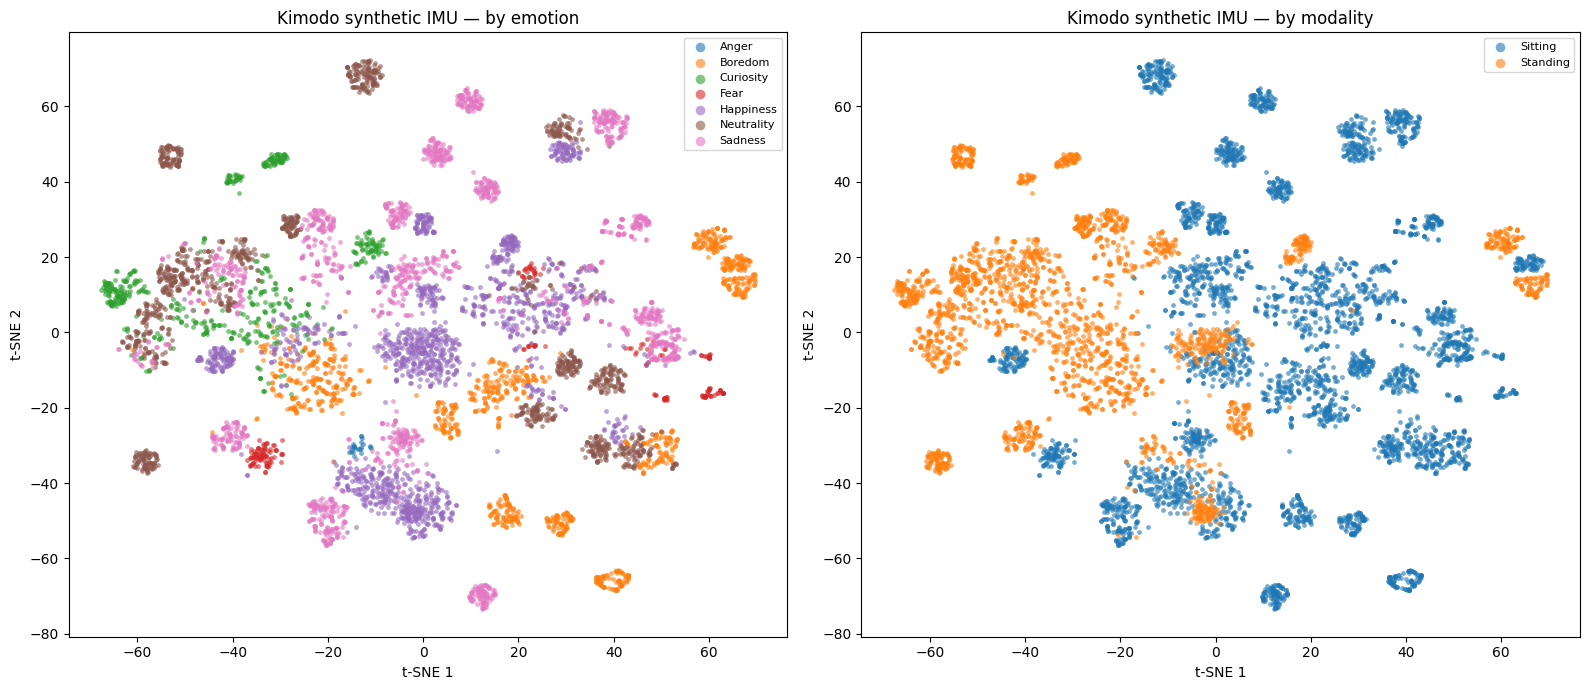

In [8]:
import matplotlib.cm as cm

def plot_tsne_by_label(emb, meta, column, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    else:
        fig = ax.figure
    classes = sorted(meta[column].dropna().unique())
    palette = cm.tab10.colors
    for i, cls in enumerate(classes):
        mask = meta[column] == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[i % len(palette)]],
                   label=cls, s=12, alpha=0.6, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=2, framealpha=0.8, fontsize=8)
    return fig, ax

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_tsne_by_label(emb_kimodo, meta_kimodo_imu, 'emotion',  'Kimodo synthetic IMU — by emotion',   axes[0])
plot_tsne_by_label(emb_kimodo, meta_kimodo_imu, 'modality', 'Kimodo synthetic IMU — by modality',  axes[1])
fig.tight_layout()
plt.show()

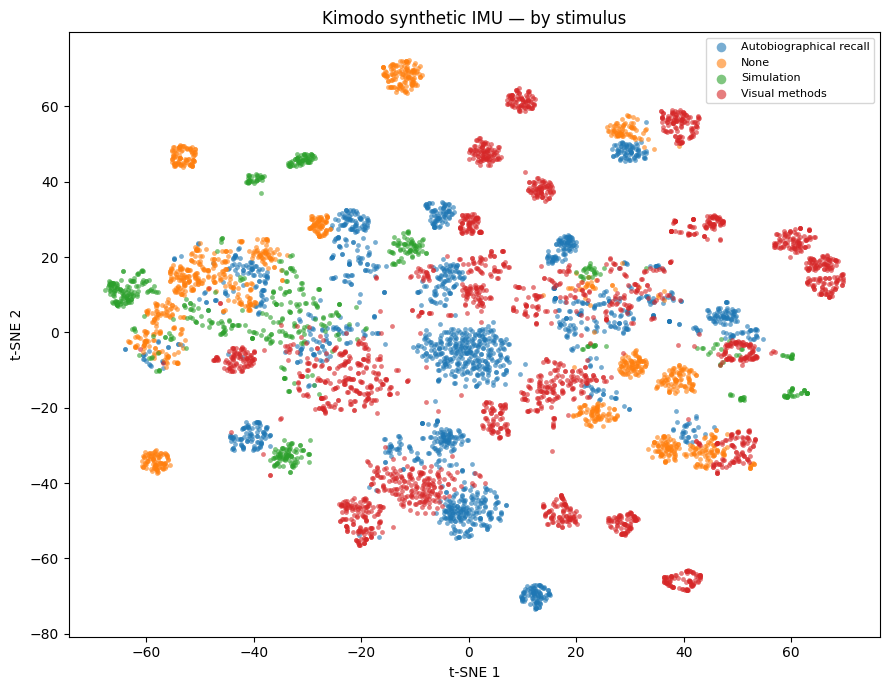

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_tsne_by_label(emb_kimodo, meta_kimodo_imu, 'stimulus', 'Kimodo synthetic IMU — by stimulus', ax)
fig.tight_layout()
plt.show()

---
## Comparison — Real IMU vs real-pose synthetic IMU, by emotion

Baseline: how well do classes cluster when the IMU comes from MotionBERT pose (not Kimodo)?
Lets us judge whether any label structure seen above is Kimodo-specific or a property of the task.

In [10]:
print('Running t-SNE on real IMU and real-pose synthetic IMU separately …')
emb_real_imu         = run_tsne(feat_real_imu,          PCA_COMPONENTS, TSNE_PERPLEXITY, TSNE_RANDOM_STATE)
emb_realpose_synth   = run_tsne(feat_realpose_synth_imu, PCA_COMPONENTS, TSNE_PERPLEXITY, TSNE_RANDOM_STATE)
print('Done.')

Running t-SNE on real IMU and real-pose synthetic IMU separately …
Done.


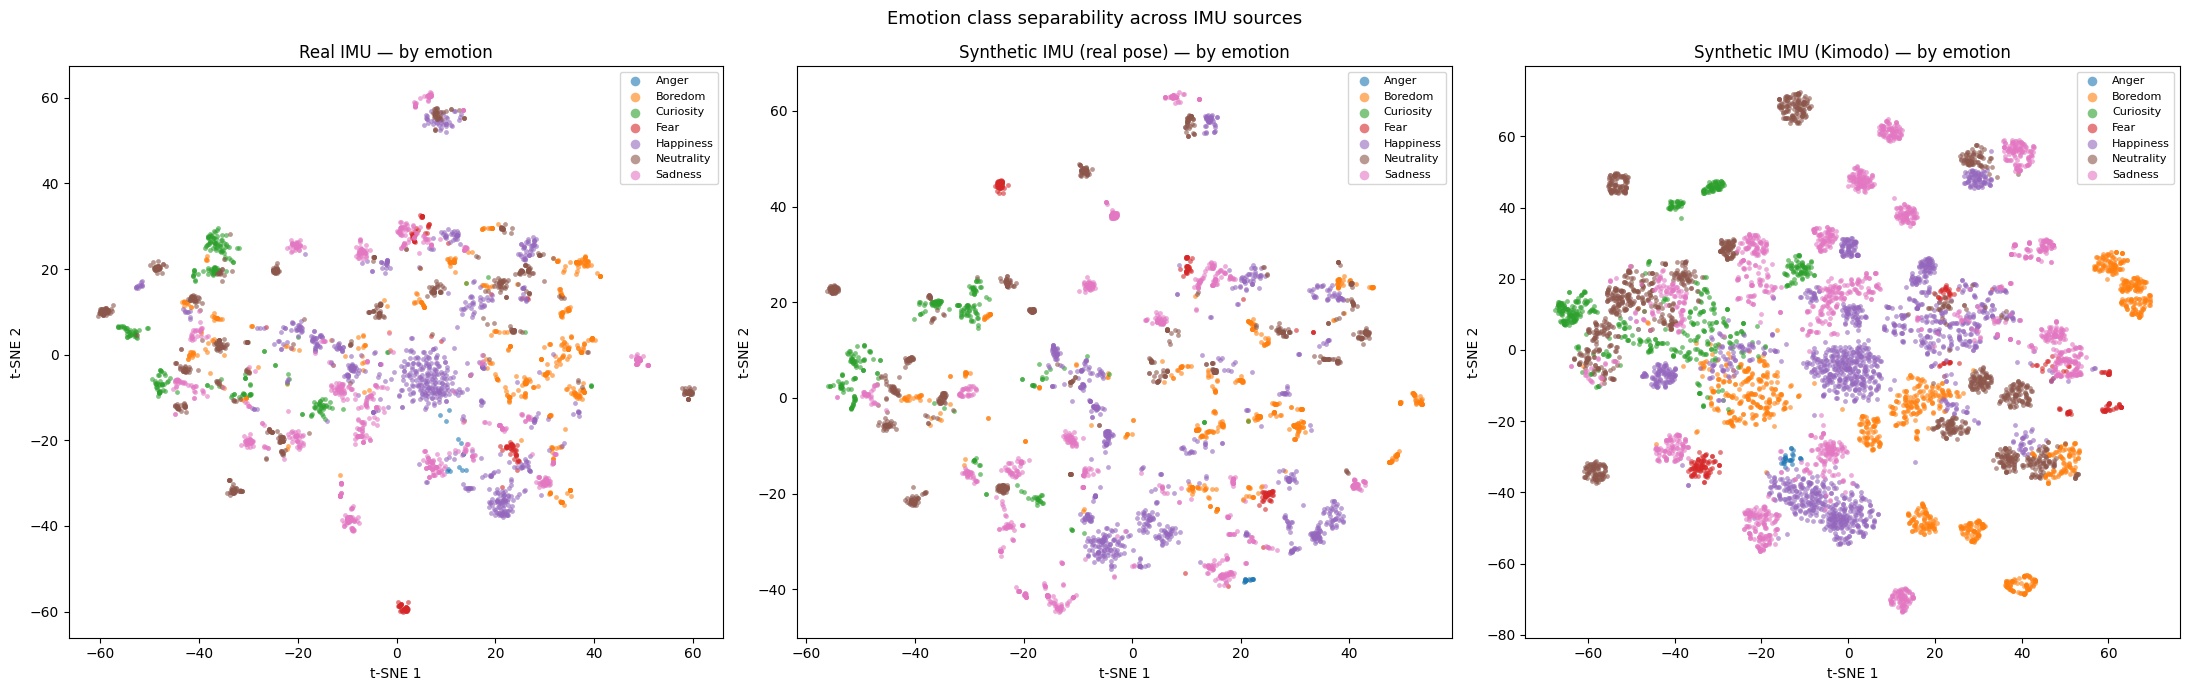

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False)
plot_tsne_by_label(emb_real_imu,       meta_real_imu,          'emotion', 'Real IMU — by emotion',                axes[0])
plot_tsne_by_label(emb_realpose_synth, meta_realpose_synth_imu, 'emotion', 'Synthetic IMU (real pose) — by emotion', axes[1])
plot_tsne_by_label(emb_kimodo,         meta_kimodo_imu,         'emotion', 'Synthetic IMU (Kimodo) — by emotion',    axes[2])
fig.suptitle('Emotion class separability across IMU sources', fontsize=13)
fig.tight_layout()
plt.show()

## Same comparison for modality (the easiest task)

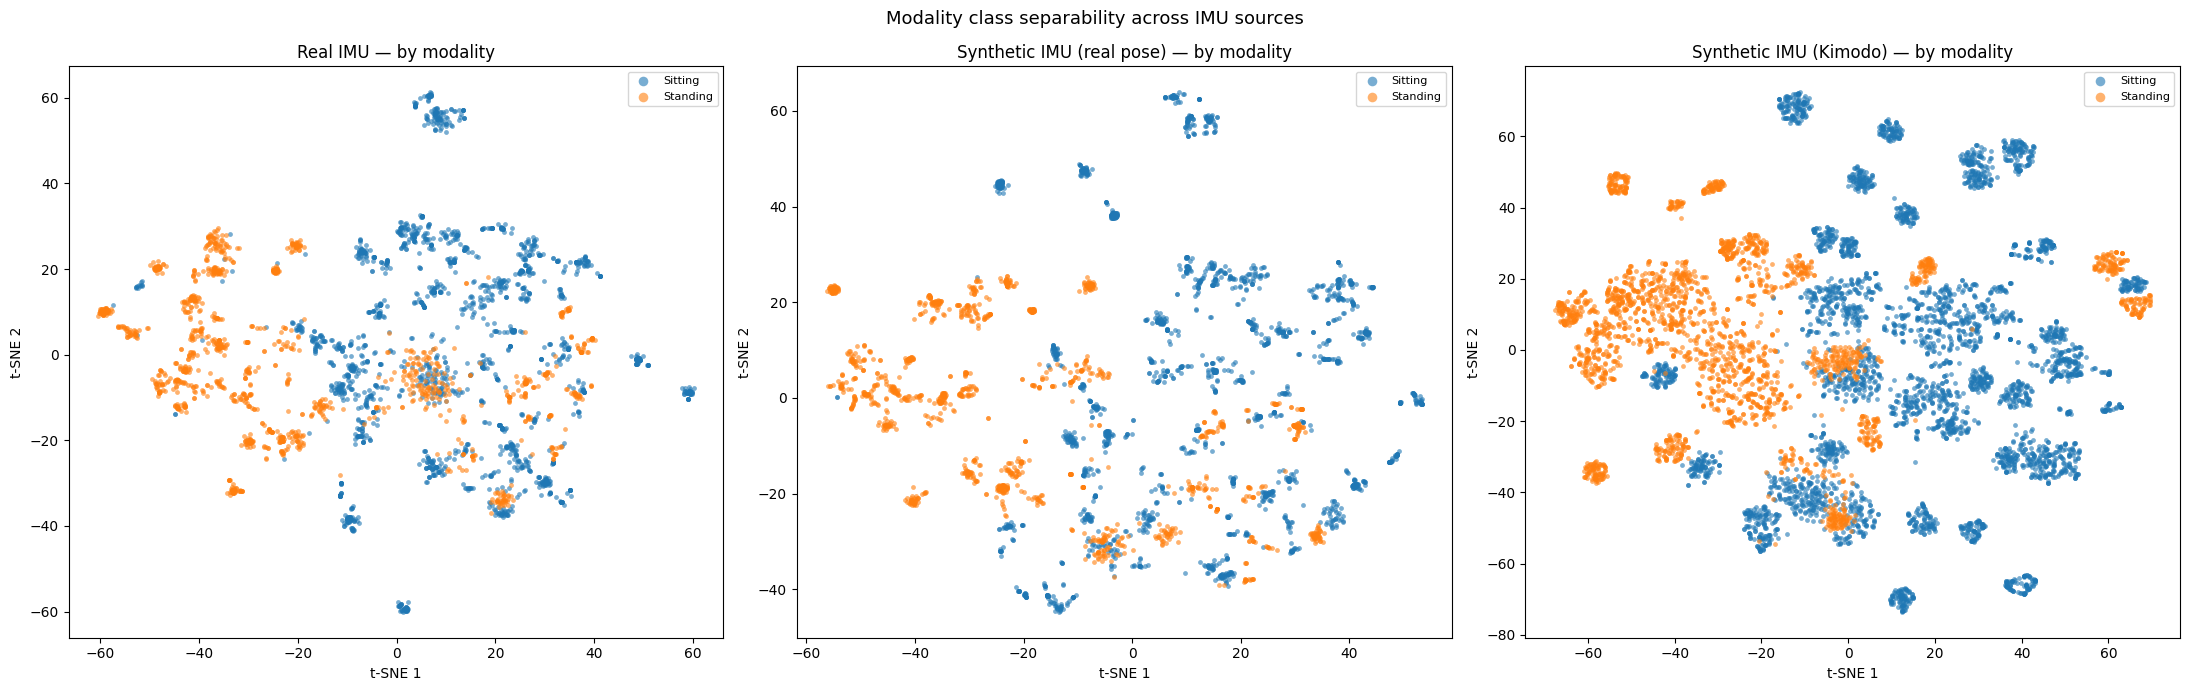

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False)
plot_tsne_by_label(emb_real_imu,       meta_real_imu,          'modality', 'Real IMU — by modality',                axes[0])
plot_tsne_by_label(emb_realpose_synth, meta_realpose_synth_imu, 'modality', 'Synthetic IMU (real pose) — by modality', axes[1])
plot_tsne_by_label(emb_kimodo,         meta_kimodo_imu,         'modality', 'Synthetic IMU (Kimodo) — by modality',    axes[2])
fig.suptitle('Modality class separability across IMU sources', fontsize=13)
fig.tight_layout()
plt.show()

---
## Interpretation guide

| Observation | Conclusion |
|---|---|
| Real IMU and Kimodo IMU in completely separate clusters (H1 plot) | Large domain gap — noise augmentation needed |
| Real-pose synth IMU overlaps with real IMU | MotionBERT noise is realistic enough |
| Kimodo IMU classes mix randomly (H2 plots) | **H1 is the problem**: Kimodo is label-agnostic, more samples won't help |
| Kimodo IMU classes cluster but separately from real | **H2 is the problem**: domain shift, not label blindness; noise aug would help |
| Modality clusters well in all sources but emotion doesn't | Task difficulty, not data quality |
